╭────────────────────────────╮
│ Higgs Boson Classification │
│ Tuned XGBoost Evaluation   │
╰────────────────────────────╯

Loading dataset...

✓ Dataset loaded successfully

Loading XGBoost model...

✓ Model loaded successfully

Generating predictions...

    Tuned XGBoost     
     Performance      
╭───────────┬────────╮
│ Metric    │ Score  │
├───────────┼────────┤
│ Accuracy  │ 0.8303 │
│ Precision │ 0.7175 │
│ Recall    │ 0.8300 │
│ F1 Score  │ 0.7696 │
│ ROC-AUC   │ 0.9116 │
╰───────────┴────────╯

╭───────────────────────────────────────────── Classification Report ─────────────────────────────────────────────╮
│               precision    recall  f1-score   support                                                           │
│                                                                                                                 │
│            0       0.90      0.83      0.87     80802                                                           │
│            1       0.72      0.83      0.77     41934                                                           │
│                                                                                                                 │
│     accuracy                           0.83    122736                                                           │
│    macro avg       0.81      0.83      0.82    122736                                                           │
│ weighted avg       0.84      0.83      0.83    122736                                                           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

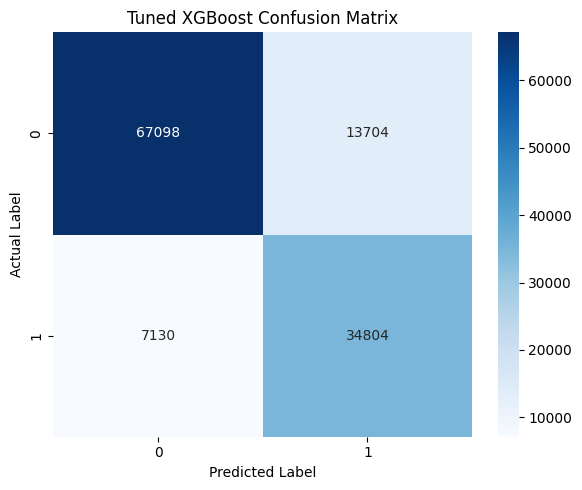

✓ Test results saved successfully

╭────── Final Results ──────╮
│                           │
│ MODEL EVALUATION COMPLETE │
│                           │
│ Accuracy  : 0.8303        │
│ Precision : 0.7175        │
│ Recall    : 0.8300        │
│ F1 Score  : 0.7696        │
│ ROC-AUC   : 0.9116        │
│                           │
╰───────────────────────────╯

In [1]:
# ============================================================
# Higgs Boson Classification
# XGBoost Model Testing Script
# ============================================================

import joblib

from preprocessing_22 import load_data_unscaled

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich.progress import Progress
from rich import box

console = Console()

# ============================================================
# Load Processed Data
# ============================================================

console.print(
    Panel.fit(
        "[bold cyan]Higgs Boson Classification[/bold cyan]\n"
        "[bold green]Tuned XGBoost Evaluation[/bold green]",
        border_style="green"
    )
)

console.print("[yellow]Loading dataset...[/yellow]")

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    feature_names
) = load_data_unscaled()

console.print(
    "[bold green]✓ Dataset loaded successfully[/bold green]"
)

# ============================================================
# Load Saved Model
# ============================================================

console.print(
    "[yellow]Loading XGBoost model...[/yellow]"
)
model = joblib.load(
    "../models/higgs_xgboost_tuned.pkl"
)

console.print(
    "[bold green]✓ Model loaded successfully[/bold green]"
)

# ============================================================
# Generate Predictions
# ============================================================

console.print("[yellow]Generating predictions...[/yellow]")

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


# ============================================================
# Calculate Performance Metrics
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

metrics_table = Table(
    title="Tuned XGBoost Performance",
    box=box.ROUNDED
)

metrics_table.add_column(
    "Metric",
    style="cyan",
    justify="left"
)

metrics_table.add_column(
    "Score",
    style="green",
    justify="center"
)

metrics_table.add_row("Accuracy", f"{accuracy:.4f}")
metrics_table.add_row("Precision", f"{precision:.4f}")
metrics_table.add_row("Recall", f"{recall:.4f}")
metrics_table.add_row("F1 Score", f"{f1:.4f}")
metrics_table.add_row("ROC-AUC", f"{auc:.4f}")

console.print(metrics_table)

# ============================================================
# Classification Report
# ============================================================

report = classification_report(
    y_test,
    y_pred
)

console.print(
    Panel(
        report,
        title="Classification Report",
        border_style="yellow"
    )
)


# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Tuned XGBoost Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()

plt.savefig(
    "../results/plots/tuned_xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Save Test Results
# ============================================================

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

results.to_csv(
    "../results/tables/tuned_xgboost_test_results.csv",
    index=False
)

console.print(
    "[bold green]✓ Test results saved successfully[/bold green]"
)


console.print(
    Panel.fit(
        f"""
[bold green]MODEL EVALUATION COMPLETE[/bold green]

Accuracy  : {accuracy:.4f}
Precision : {precision:.4f}
Recall    : {recall:.4f}
F1 Score  : {f1:.4f}
ROC-AUC   : {auc:.4f}
        """,
        title="Final Results",
        border_style="bright_green"
    )
)